# Assignment: Image Denoising using an MNIST Autoencoder


In [1]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

np.random.seed(42)
tf.random.set_seed(42)


## Step 1: Load dataset



In [2]:

(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.reshape(x_train, (-1,28,28,1))
x_test = np.reshape(x_test, (-1,28,28,1))

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)


## Step 2: Adding random noise

In [3]:

noise_factor = 0.5

x_train_noisy = x_train + noise_factor*np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor*np.random.normal(size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy,0.,1.)
x_test_noisy = np.clip(x_test_noisy,0.,1.)


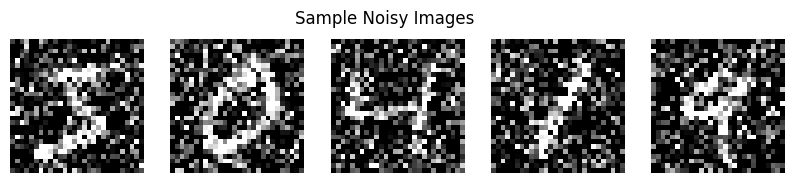

In [4]:

plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap="gray")
    plt.axis("off")
plt.suptitle("Sample Noisy Images")
plt.show()


## Step 3: Autoencoder

In [5]:

input_img = Input(shape=(28,28,1))

x = Conv2D(32,(3,3),activation="relu",padding="same")(input_img)
x = MaxPooling2D((2,2),padding="same")(x)
x = Conv2D(32,(3,3),activation="relu",padding="same")(x)
encoded = MaxPooling2D((2,2),padding="same")(x)

x = Conv2D(32,(3,3),activation="relu",padding="same")(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(32,(3,3),activation="relu",padding="same")(x)
x = UpSampling2D((2,2))(x)
decoded = Conv2D(1,(3,3),activation="sigmoid",padding="same")(x)

autoencoder = Model(input_img, decoded)

autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

## Step 4: Train the model

In [6]:

history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 298ms/step - loss: 0.1591 - val_loss: 0.1157
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 136s 290ms/step - loss: 0.1122 - val_loss: 0.1072
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 134s 286ms/step - loss: 0.1066 - val_loss: 0.1038
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 137s 293ms/step - loss: 0.1040 - val_loss: 0.1019
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 138s 283ms/step - loss: 0.1023 - val_loss: 0.1006
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 139s 277ms/step - loss: 0.1010 - val_loss: 0.0996
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 277ms/step - loss: 0.1000 - val_loss: 0.0988
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 131s 280ms/step - loss: 0.0993 - val_loss: 0.0981
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 279ms/step - loss: 0.0986 - val_loss: 0.0974
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 129s 276ms/step - loss: 0.0980 - val_loss: 0.0969


## Step 5: Predict the clean images

In [7]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step


## Step 6: Compare the results

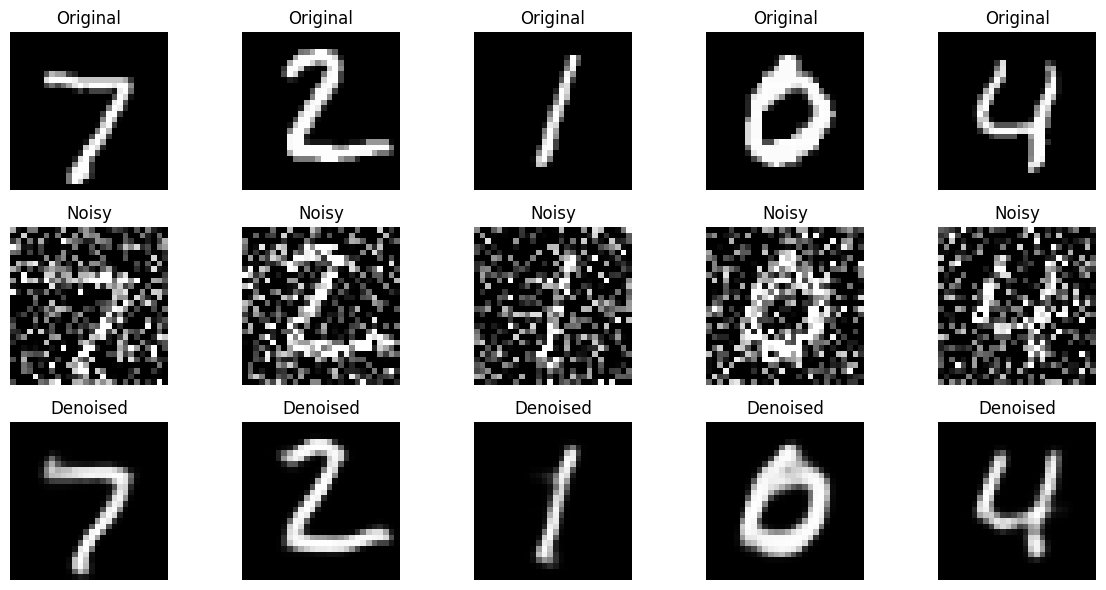

In [8]:

n = 5
plt.figure(figsize=(12,6))

for i in range(n):
    ax = plt.subplot(3,n,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    ax = plt.subplot(3,n,i+1+n)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    ax = plt.subplot(3,n,i+1+2*n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()
